In [156]:
print("tt")

tt


In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [158]:
df =pd.read_csv('read.csv')

In [159]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

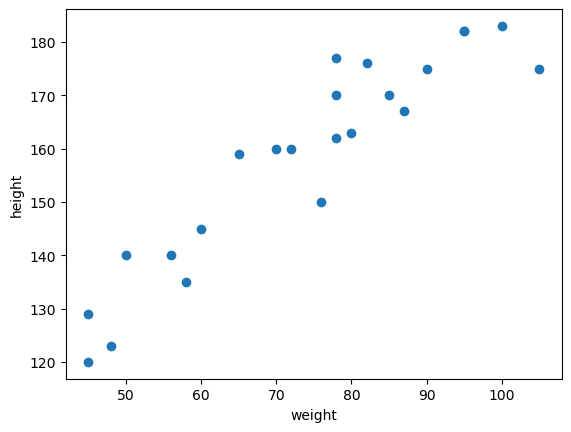

In [160]:
#scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('weight')
plt.ylabel('height')

In [161]:
#coorelation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [162]:
import seaborn as sns

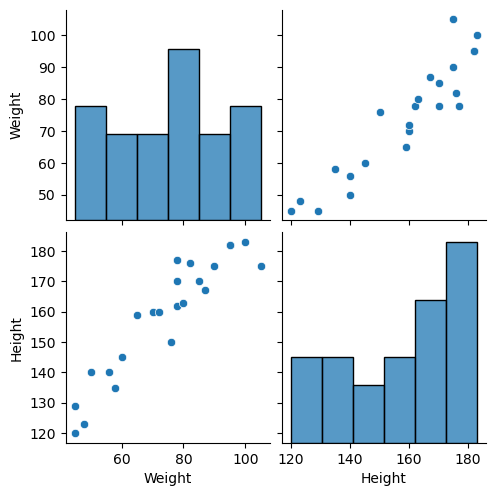

In [163]:
sns.pairplot(df)

In [164]:
#make sure your independent feature should be dataframe
X=df[['Weight']]
np.array(X).shape
#this is in 2d array if['height_cm']it is 1d array so independent fetaure should 
#be a dataframe or 2d array

(23, 1)

In [165]:
#dependent feature can be series
Y=df['Height']
np.array(Y).shape


(23,)

In [166]:
#train test split for under and over fitting condition
from sklearn.model_selection import train_test_split

In [167]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=.25,random_state=42)

In [168]:
X_train.shape

(17, 1)

In [169]:
##Standardization means mean=0 and SD =1
from sklearn.preprocessing import StandardScaler

In [170]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [171]:
x_test=scaler.transform(X_test)

In [172]:
X_test

,Weight
15,78
9,78
0,45
8,95
17,65
12,105


In [173]:
#apply linear regression
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [174]:
regression.coef_

array([17.2982057])

In [175]:
regression.fit_intercept

True

In [176]:
regression.intercept_

np.float64(156.47058823529412)

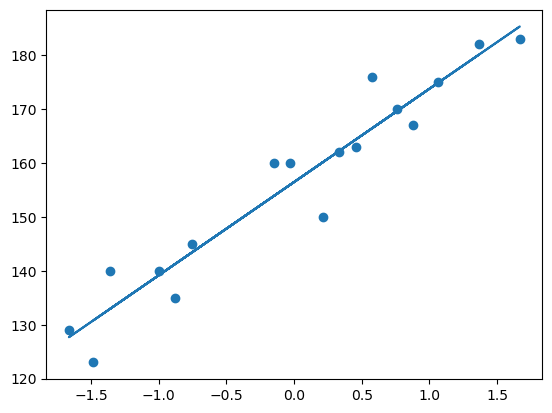

In [177]:
#plot training data best fit line
plt.scatter(X_train,Y_train)
plt.plot(X_train, regression.predict(X_train))


In [178]:
#for test data
Y_pred=regression.predict(X_test)
 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [180]:
#performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [181]:
mse=mean_squared_error(Y_test,Y_pred)
mae=mean_absolute_error(Y_test,Y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

1886933.5397307768
1336.131231274159
1373.6569949338798


In [183]:
from sklearn.metrics import r2_score
score=r2_score(Y_test,Y_pred)
print(score)


-4335.39370764813


In [185]:
#ols linear regression
import statsmodels.api as sm
#model=sm.OLS(Y_train,X_train).fit()
#prediction=model.predict(X_train)
#print(prediction)

In [188]:
model=sm.OLS(Y_train,X_train).fit()
prediction=model.predict(X_train)
print(prediction)

[-15.16409156  28.84875956   5.79440897 -25.64334183  23.60913442
 -28.78711691 -13.06824151  -2.58899124   3.69855892 -23.54749178
 -17.25994162  -0.49314119  18.36950929   9.98610908  13.12988416
  15.22573421   7.89025902]


In [189]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 20 Sep 2026   Prob (F-statistic):                       0.664
Time:                        01:47:11   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [ ]:
#prediction for new data
regression.predict(scaler.transform([[72]]))
#scaling was very imp for new data 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])